# Numerical Methods for Solving Linear Systems #

$Author$: Michael Simons

$Class$: MTH 437 - Numerical Analysis

$Date$: 10/24/23

## Introduction ##

This project will aim to explore two iterative methods for solving the linear system $Ax = b$, where A is a symmetric positive definite matrix. The preconditioner that will be utilized in both methods is based on Jacobi Iteration: $P = D = diag(A)$. To estimate the error in each method, the relative residual $\frac{||r_k||}{||b||}$ where $r_k = b-Ax_k$. A tolerance $ε = 10^{-10}$ will be chosen.

## Gauss-Seidel Method ##

This section will focus on the Gauss-Seidel Method for solving a linear system $Ax = b$, where $A$ is a symmetric positive definite matrix. A file titled `A.dat` contains a $1600 x 1600$ matrix which will be read using pandas. The vector $b$ will then be generated in preparation for applying the Gauss-Seidel Method.

In [1]:
import pandas as pd 
import numpy as np
A = pd.read_csv('A.dat', header=None).values  #Read the matrix. values function sets type to np array
x_t = np.ones(A.shape[0])  #Create a vector of ones
b = np.dot(A, x_t)  #Calculate b using matrix multiplication
epsilon = 1e-10  #Set the tolerance (10^-10)

The matrix $A$ has now been read into a numpy array, and $b$ has been generated. A function to encapsulate the Gauss-Seidel Method will now be implemented. The idea of the algorithm is to directly update the vector values of the solution, and compute the residual of the updated solution until the tolerance, $ε = 10^{-10}$ is met. At each iteration, the residual norm will be added to a container which will be returned along with the solution.

In [2]:
def gauss_seidel_method(A, b, epsilon):
    n = A.shape[0]  #Get the size of the system
    x = np.zeros(n)  #Initialize the solution vector
    residual_norms = []  #Container for residual norms
    iteration = 0
    tolerance_met = False
    while not tolerance_met:
        for i in range(n):
            sum1 = np.dot(A[i, :i], x[:i]) #Sum left of the diagonal
            sum2 = np.dot(A[i, i+1:], x[i+1:]) #Sum right of the diagonal
            x[i] = (b[i] - sum1 - sum2) / A[i, i] #Update x
        residual = b - np.dot(A, x)  #Calculate the residual
        residual_norm = np.linalg.norm(residual) / np.linalg.norm(b) #Calculate relative residual
        residual_norms.append(residual_norm)  #Add to the container
        if residual_norm < epsilon:
            tolerance_met = True
        iteration += 1
    return x, residual_norms

With the method implemented, the loaded matrix and previously generated value $b$ will soon be utilized, and a plot be generated using the list of residual norms to observe the relative residual at each iteration. 

## Preconditioned Steepest Descent ##

This section will focus on the implementation of the Preconditioned Steepest Descent method for solving the linear system. As previously described, the preconditioner utilized in this method is based on the Jacobi Iteration. 

A function will now be developed to capture the method. Similar to the previous method, the function will iteratively update the solution until the residual falls below the tolerance $ε = 10^{-10}$. The difference is that while Gauss-Seidel updates the solution component-wise, Preconditioned Steepest Descent relies on solving a preconditionining equation. At each iteration, the residual norm will be tracked using a container which will be returned along with the solution.

In [3]:
def preconditioned_steepest_descent(A, b, epsilon):
    n = A.shape[0]
    x = np.zeros(n)
    r = b - np.dot(A, x)
    residual_norms = []
    iteration = 0
    tolerance_met = False
    while not tolerance_met:
        z = r / np.diag(A)  #Solve Pz = r (Jacobi preconditioner)
        alpha = np.dot(z, r) / np.dot(z, np.dot(A, z))  #Calculate alpha
        x = x + alpha * z  #Update solution
        r = r - alpha * np.dot(A, z)  #Update residual
        residual_norm = np.linalg.norm(r) / np.linalg.norm(b)  #Calculate relative residual
        residual_norms.append(residual_norm)
        if residual_norm < epsilon:
            tolerance_met = True
        iteration += 1
    return x, residual_norms

The method is now implemented, and the loaded matrix and generated value $b$ will now be utilized. Again, a plot will be generated using the returned list of residual norms to observe the relative residual at each iteration. 

## Convergence Comparison ##

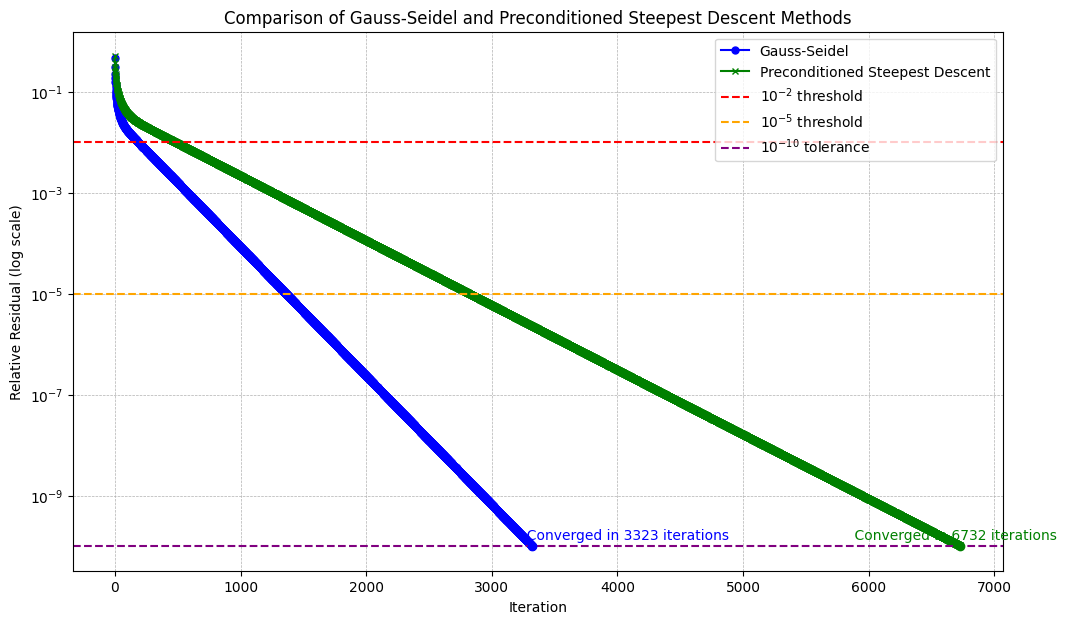

In [4]:
import matplotlib.pyplot as plt

solutions_gs, residuals_gs = gauss_seidel_method(A, b, epsilon)
solution_psd, residuals_psd = preconditioned_steepest_descent(A, b, epsilon)

plt.figure(figsize=(12, 7))

#Gauss-Seidel method
plt.plot(range(len(residuals_gs)), residuals_gs, label='Gauss-Seidel', color='blue', marker='o', linestyle='-', markersize=5)
plt.scatter(len(residuals_gs)-1, residuals_gs[-1], color='blue', zorder=5)  # Convergence point
plt.annotate(f"                                                  Converged in {len(residuals_gs)} iterations", 
             (len(residuals_gs)-1, residuals_gs[-1]), 
             textcoords="offset points", xytext=(-10,5), ha='center', color='blue')

#Preconditioned Steepest Descent method
plt.plot(range(len(residuals_psd)), residuals_psd, label='Preconditioned Steepest Descent', color='green', marker='x', linestyle='-', markersize=5)
plt.scatter(len(residuals_psd)-1, residuals_psd[-1], color='green', zorder=5)  # Convergence point
plt.annotate(f"    Converged in {len(residuals_psd)} iterations", 
             (len(residuals_psd)-1, residuals_psd[-1]), 
             textcoords="offset points", xytext=(-10,5), ha='center', color='green')

#Logarithmic scale for residuals
plt.yscale('log')

# Adding threshold lines
plt.axhline(y=1e-2, color='red', linestyle='--', label=r'$10^{-2}$ threshold')
plt.axhline(y=1e-5, color='orange', linestyle='--', label=r'$10^{-5}$ threshold')
plt.axhline(y=1e-10, color='purple', linestyle='--', label=r'$10^{-10}$ tolerance')

plt.xlabel('Iteration')
plt.ylabel('Relative Residual (log scale)')
plt.title('Comparison of Gauss-Seidel and Preconditioned Steepest Descent Methods')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

The comparison reveals significant differences in convergence rates. While both methods exhibit a steady decrease in the relative residuals, it is evident that the Preconditioned Steepest Descent method achieves convergence at a notably faster pace, reaching a tolerance of $10^{−10}$ in 6732 iterations, compared to 3323 iterations required by the Gauss-Seidel method. The superior performance of the Preconditioned Steepest Descent method can be attributed to the incorporation of a preconditioner, which accelerates the rate of convergence by transforming the system into a more favorable form. Despite this, the Gauss-Seidel method maintains competitive performance, particularly in early iterations, with both methods crossing the $10^{−5}$ threshold within similar timeframes. The overall comparison highlights the advantage of preconditioning in iterative solvers, especially for problems requiring higher precision.

## Conclusion ##

Gauss-Seidel and Preconditioned Steepest Descent were both utilized to solve a linear system with a symmetric positive definite matrix. Each method effectively reduced the relative residual to the specified tolerance $ε = 10^{-10}$, as demonstrated by their respective plots of relative residuals against iteration number. This report demonstrates the applicability and practical use of these methods in approximating solutions for linear systems.